# 篇末综合 部分观测下的约束控制

## 学习目标与先修知识

在同一人工系统上检查反馈（feedback）、观测（observation）、最优决策及独立闭环评价。

先修：10.1—10.7全部课节；第7篇的状态（state）估计、第8篇二次优化与第9篇独立预测评价。

## 具体问题

人工温度偏差系统只测得第一状态，有执行限幅和扰动。如何从传感器与执行器条件、估计误差、控制输入（input）、约束求解一直走到独立评价，而不偷用模拟真值？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先核对给定二维系统是否能控、能观，并观察同一反馈增益（gain）下请求与实际输入可能不同。

In [2]:
A=np.array([[.9,.1],[0.,.95]]);B=np.array([.1,.2]);C=np.array([1.,0.]);print("能控行列式：",np.linalg.det(np.column_stack([B,A@B])));print("能观行列式：",np.linalg.det(np.vstack([C,C@A])))

能控行列式： -0.003000000000000002
能观行列式： 0.10000000000000002


## 模型假设

教学二维离散对象 $x^+=Ax+Bu+d$，A、B、C在初步实验给出，读数 y=Cx+v，传感器只直接测量第一状态；第二状态会影响第一状态的后续变化，因此结合已知方程和多个时刻的读数，可以估计两维状态。噪声和扰动仍会造成估计误差。控制器获得y、已执行u和模型（model）参数（parameter）；真值x只存于隔离的评价变量。执行限幅±0.4；人工扰动与噪声固定种子。此处反馈增益和估计增益是预先选定的可运行基线，不声称全局最优。LQR与MPC的小型问题另用一维约简，须明确这一简化。

## 数学解释与推导

完整链路依次检查：(1) $[B,AB]$ 与 $[C;CA]$ 的秩（rank）；(2) 观测器 $\hat x^+=A\hat x+B u+L(y-C\hat x)$；(3) 控制请求 $u_{req}=-K\hat x$ 和执行 $u=\operatorname{clip}(u_{req},\pm0.4)$；(4) 以真实执行输入推进对象，并在独立场景报告误差、输入与失败。

有限时域LQR通过Bellman/Riccati解无约束二次问题；MPC在此给定的离散行动集上枚举硬约束轨迹（trajectory）。二者的最优性陈述限于各自的模型、目标、信息和行动集合。把LQR输入简单裁剪不是原有约束MPC的最优性证明。若实际对象失配、缺测或求解不可行，需保留失败并另做验证。

本篇的独立评价要锁定调参结果，双方使用相同传感器、扰动场景、执行上限与预算。完整状态反馈只作为额外信息参考，不能与部分观测方法称为同等信息的比赛。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def controllability_2d(A, B):
    AB = [A[i][0] * B[0] + A[i][1] * B[1] for i in range(2)]
    matrix = [[B[0], AB[0]], [B[1], AB[1]]]
    determinant = matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]
    return matrix, determinant


def observability_2d(A, C):
    CA = [C[0] * A[0][j] + C[1] * A[1][j] for j in range(2)]
    matrix = [[C[0], C[1]], CA]
    determinant = matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]
    return matrix, determinant


def observer_path(A, B, C, L, inputs, readings, initial):
    """Discrete observer, known inputs and readings; no hidden true state."""
    estimate = list(initial)
    path = [estimate.copy()]
    innovations = []
    for u, y in zip(inputs, readings):
        innovation = y - sum(C[j] * estimate[j] for j in range(2))
        estimate = [sum(A[i][j] * estimate[j] for j in range(2))
                    + B[i] * u + L[i] * innovation for i in range(2)]
        innovations.append(innovation)
        path.append(estimate)
    return path, innovations


def finite_lqr(A, B, Q, R, terminal, horizon):
    """Finite-horizon discrete Riccati; NumPy is the only extra dependency."""
    import numpy as np
    a, b = np.asarray(A, float), np.asarray(B, float)
    q, r = np.asarray(Q, float), np.asarray(R, float)
    s = np.asarray(terminal, float)
    gains = [None] * horizon
    values = [None] * (horizon + 1)
    values[horizon] = s.tolist()
    for t in range(horizon - 1, -1, -1):
        inverse = np.linalg.solve(r + b.T @ s @ b, b.T @ s @ a)
        gains[t] = inverse.tolist()
        s = q + a.T @ s @ a - a.T @ s @ b @ inverse
        s = (s + s.T) / 2
        values[t] = s.tolist()
    return gains, values


def discrete_mpc(state, a, b, target, q, r, terminal, actions, horizon, lower, upper):
    """Exact enumeration of a small *discrete-action* MPC, not continuous MPC."""
    best = None
    for sequence in itertools.product(actions, repeat=horizon):
        x = state
        cost = 0.0
        path = [x]
        for u in sequence:
            cost += q * (x - target) ** 2 + r * u * u
            x = a * x + b * u
            path.append(x)
            if not lower <= x <= upper:
                break
        else:
            cost += terminal * (x - target) ** 2
            candidate = (cost, sequence, path)
            if best is None or candidate[:2] < best[:2]:
                best = candidate
    if best is None:
        return 'infeasible', None, None, []
    cost, sequence, path = best
    return 'optimal', sequence[0], cost, path


def paired_metrics(targets, trajectories, applied, limit, failed):
    """One scenario; failed still counts in the denominator outside this helper."""
    if failed:
        return None, None, None, True
    error = sum((x - goal) ** 2 for x, goal in zip(trajectories, targets)) / len(targets)
    effort = sum(u * u for u in applied) / len(applied) if applied else 0.0
    violation = max([max(0.0, abs(u) - limit) for u in applied] or [0.0])
    return error, effort, violation, False

## 对照实验

用同一固定噪声与扰动运行二维输出（output）反馈，控制决策只读取估计；展示实际状态、估计、请求输入和限幅后输入。再独立算一个标量LQR与离散MPC，比较它们各自的契约。

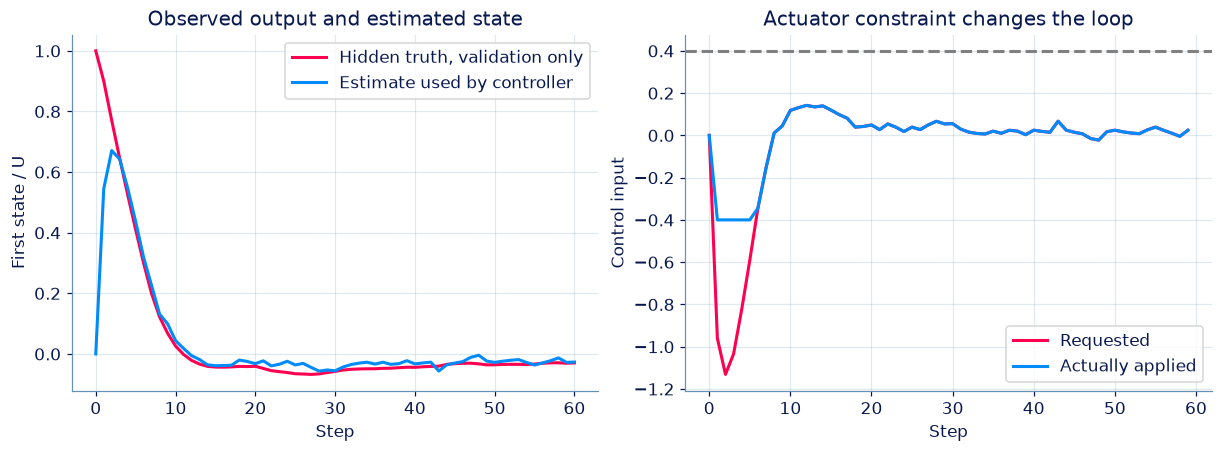

二维能控/能观行列式： -0.0030000000000000027 0.1
标量无约束LQR： [[[0.8315631168342889]], [[0.9729729729729731]]]
离散行动MPC： ('optimal', -0.4, 1.5548119999999999, [1.0, 0.58, 0.20199999999999996])


In [4]:
L=np.array([.55,.18]);K=np.array([1.5,.8]);limit=.4
rng=np.random.default_rng(10100);noise=rng.normal(0,.015,60);disturbance=np.r_[np.zeros(20),np.full(40,-.01)]
actual=np.array([1.,0.]);estimate=np.zeros(2);states=[actual.copy()];estimates=[estimate.copy()];requests=[];applied=[]
for t in range(60):
    reading=float(C@actual+noise[t]);request=-float(K@estimate);u=float(np.clip(request,-limit,limit))
    correction=reading-C@estimate
    next_estimate=A@estimate+B*u+L*correction
    actual=A@actual+B*u+np.array([disturbance[t],0.]);estimate=next_estimate
    states.append(actual.copy());estimates.append(estimate.copy());requests.append(request);applied.append(u)
states=np.array(states);estimates=np.array(estimates)
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(states[:,0],label='Hidden truth, validation only',color=PINK);axes[0].plot(estimates[:,0],label='Estimate used by controller',color=BLUE)
axes[0].set(xlabel='Step',ylabel='First state / U',title='Observed output and estimated state');axes[0].legend()
axes[1].plot(requests,label='Requested',color=PINK);axes[1].plot(applied,label='Actually applied',color=BLUE);axes[1].axhline(limit,color='gray',ls='--')
axes[1].set(xlabel='Step',ylabel='Control input',title='Actuator constraint changes the loop');axes[1].legend();plt.show()
print('二维能控/能观行列式：',controllability_2d(A.tolist(),B.tolist())[1],observability_2d(A.tolist(),C.tolist())[1])
print('标量无约束LQR：',finite_lqr([[.9]],[[.8]],[[1.]],[[.3]],[[3.]],2)[0])
print('离散行动MPC：',discrete_mpc(1.,.9,.8,0.,1.,.3,3.,[-.4,0.,.4],2,-1.,2.))

## 结果解释

同一观测接口下，估计初态误差逐步变化；控制器看到的是估计，不是图中的隐藏真值。请求与实际输入可不同，真实状态只用实际输入推进。下方两个最优控制小例的维度和行动集合已明确，不应把它们的单次数字与二维输出反馈曲线直接排成“最佳算法”名次。

### 独立核对

核对能控与能观结构，实际限幅，首步只由初始估计产生控制请求，并用直接代价核验标量LQR一步结果。

In [5]:
assert abs(controllability_2d(A.tolist(),B.tolist())[1])>1e-6
assert abs(observability_2d(A.tolist(),C.tolist())[1])>1e-6
assert requests[0]==0. and max(abs(u) for u in applied)<=limit+1e-12
gain,value=finite_lqr([[1.]],[[1.]],[[1.]],[[1.]],[[1.]],1)
np.testing.assert_allclose(gain[0],[[.5]]);np.testing.assert_allclose(value[0],[[1.5]])
print('信息边界、限幅与Bellman标量参照通过。')

信息边界、限幅与Bellman标量参照通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：反馈方向与稳定证据

对稳定一阶对象施加恒定负扰动，控制器误差定义为设定−测量。哪个判断正确？

- **A.** P可能留下稳态误差；加入积分须重新核验动态和限幅。
- **B.** PI永远无条件稳定。
- **C.** 只看请求输入（input）即可知道对象轨迹（trajectory）。
- **D.** 频域裕度保证所有饱和状态（state）下安全。

[作答：反馈方向与稳定证据](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-feedback)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：执行器与传感器配置

A=[[0,1],[0,0]]，候选B₁=[0,1]ᵀ、B₂=[1,0]ᵀ；候选C₁=[1,0]、C₂=[0,1]。哪组同时满足二维能控与能观？

- **A.** B₁、C₁。
- **B.** B₁、C₂。
- **C.** B₂、C₁。
- **D.** B₂、C₂。

[作答：执行器与传感器配置](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-sensors)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：限幅下的控制一步

复用本篇条件积分的PI规则；返回请求、实际输入（input）和积分状态（state）。把这个步骤用于人工温度偏差场景，但不假装已经给出完整临床控制建议。

**函数与代码模板**

```python
def solve(
    error: float,
    integral: float,
    dt: float,
    kp: float,
    ki: float,
    limit: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `error` | `float` | 当前误差。 | U |
| `integral` | `float` | 旧积分状态。 | U·T |
| `dt` | `float` | 时间步。 | T |
| `kp` | `float` | 比例增益（gain）。 | 1/T |
| `ki` | `float` | 积分增益。 | 1/T² |
| `limit` | `float` | 执行上限。 | U/T |

**返回值**

按以下顺序返回元组：(requested, actual, new_integral)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `requested` | `float` | 冻结判定后请求。 | U/T |
| `actual` | `float` | 实际限幅输入。 | U/T |
| `new_integral` | `float` | 下一积分状态。 | U·T |

**计算规则**

先试积分；若饱和且误差推动同向限幅，则冻结并重新计算。

**约束与边界**

- 输入均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| error | 当前误差。 | 3 | U |
| integral | 旧积分状态。 | 1 | U·T |
| dt | 时间步。 | 0.5 | T |
| kp | 比例增益（gain）。 | 0.5 | 1/T |
| ki | 积分增益。 | 1 | 1/T² |
| limit | 执行上限。 | 2 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
error = 3.0
integral = 1.0
dt = 0.5
kp = 0.5
ki = 1.0
limit = 2.0

result = solve(error, integral, dt, kp, ki, limit)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| requested | 冻结判定后请求。 | 2.5 | U/T |
| actual | 实际限幅输入。 | 2 | U/T |
| new_integral | 下一积分状态。 | 1 | U·T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (2.5, 2.0, 1.0)
```

**样例解释**

必须让实际输入进入对象模型，而不是用未执行的请求输入。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：限幅下的控制一步](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-pid)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：给定读数下的观测器

按题给已知输入（input）、读数与增益（gain）重放估计轨迹（trajectory）。输入中没有模拟真值；真值只能另外用于离线核验。

**函数与代码模板**

```python
def solve(
    A: list[list[float]],
    B: list[float],
    C: list[float],
    L: list[float],
    inputs: list[float],
    readings: list[float],
    initial: list[float],
) -> tuple[list[list[float]], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A` | `list[list[float]]` | 二维状态（state）矩阵（matrix）。 | 按状态 |
| `B` | `list[float]` | 输入列。 | 状态/输入 |
| `C` | `list[float]` | 观测（observation）行。 | 观测/状态 |
| `L` | `list[float]` | 观测增益。 | 状态/观测 |
| `inputs` | `list[float]` | 实际输入序列。 | 输入 |
| `readings` | `list[float]` | 读数序列。 | 观测 |
| `initial` | `list[float]` | 初始估计。 | 状态 |

**返回值**

按以下顺序返回元组：(path, innovations)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `path` | `list[list[float]]` | 估计轨迹，含初值（initial condition）。 | 状态 |
| `innovations` | `list[float]` | 每一步创新。 | 观测 |

**计算规则**

xhat_next=A xhat+B u+L(y−C xhat)，同步记录创新。

**约束与边界**

- 输入均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A | 二维状态（state）矩阵（matrix）。 | [[1.0, 1.0], [0.0, 1.0]] | 按状态 |
| B | 输入列。 | [0.0, 1.0] | 状态/输入 |
| C | 观测（observation）行。 | [1.0, 0.0] | 观测/状态 |
| L | 观测增益。 | [0.4, 0.2] | 状态/观测 |
| inputs | 实际输入序列。 | [1.0, 0.0] | 输入 |
| readings | 读数序列。 | [1.0, 2.0] | 观测 |
| initial | 初始估计。 | [0.0, 0.0] | 状态 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A = [[1.0, 1.0], [0.0, 1.0]]
B = [0.0, 1.0]
C = [1.0, 0.0]
L = [0.4, 0.2]
inputs = [1.0, 0.0]
readings = [1.0, 2.0]
initial = [0.0, 0.0]

result = solve(A, B, C, L, inputs, readings, initial)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| path | 估计轨迹，含初值（initial condition）。 | [[0.0, 0.0], [0.4, 1.2], [2.24, 1.52]] | 状态 |
| innovations | 每一步创新。 | [1.0, 1.6] | 观测 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.0, 0.0], [0.4, 1.2], [2.24, 1.52]],
                   [1.0, 1.6])
```

**样例解释**

第一步创新为1；读数校正和已知输入作用分别进入下一估计。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：给定读数下的观测器](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-observer)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：综合题中的有限时域LQR

在题给无约束线性二次模型（model）中倒推价值矩阵（matrix）与反馈（feedback）增益（gain）。不要把输入（input）限幅后的轨迹（trajectory）声称为此题的无约束最优解。

**函数与代码模板**

```python
def solve(
    A: list[list[float]],
    B: list[list[float]],
    Q: list[list[float]],
    R: list[list[float]],
    terminal: list[list[float]],
    horizon: int,
) -> tuple[list[list[list[float]]], list[list[list[float]]]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A` | `list[list[float]]` | 状态（state）矩阵。 | 按状态 |
| `B` | `list[list[float]]` | 输入矩阵。 | 状态/输入 |
| `Q` | `list[list[float]]` | 阶段状态权重。 | 代价/状态² |
| `R` | `list[list[float]]` | 输入权重。 | 代价/输入² |
| `terminal` | `list[list[float]]` | 终端权重。 | 代价/状态² |
| `horizon` | `int` | 有限时域。 | 步 |

**返回值**

按以下顺序返回元组：(gains, values)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gains` | `list[list[list[float]]]` | 逐时刻反馈矩阵。 | 输入/状态 |
| `values` | `list[list[list[float]]]` | 含终端的代价矩阵。 | 代价/状态² |

**计算规则**

以终端S_N开始，求解线性方程得到K_t，再倒推S_t。

**约束与边界**

- 矩阵满足10.5.2的维数及半正定（positive semidefinite）/正定（positive definite）条件；1≤horizon≤8；可使用numpy。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A | 状态（state）矩阵。 | [[1.0]] | 按状态 |
| B | 输入矩阵。 | [[1.0]] | 状态/输入 |
| Q | 阶段状态权重。 | [[1.0]] | 代价/状态² |
| R | 输入权重。 | [[2.0]] | 代价/输入² |
| terminal | 终端权重。 | [[3.0]] | 代价/状态² |
| horizon | 有限时域。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A = [[1.0]]
B = [[1.0]]
Q = [[1.0]]
R = [[2.0]]
terminal = [[3.0]]
horizon = 2

result = solve(A, B, Q, R, terminal, horizon)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gains | 逐时刻反馈矩阵。 | [[[0.5238095238095238]], [[0.6]]] | 输入/状态 |
| values | 含终端的代价矩阵。 | [[[2.0476190476190474]], [[2.2]], [[3.0]]] | 代价/状态² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[[0.5238095238095238]], [[0.6]]],
                   [[[2.0476190476190474]],
                    [[2.2]],
                    [[3.0]]])
```

**样例解释**

先核对标量递推，再核对二维矩阵的对称性和闭环代价。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题中的有限时域LQR](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-riccati)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：综合题中的滚动约束求解

在小型离散行动集上给出硬状态（state）界与固定时域，返回当前最优首步、成本、预测轨迹（trajectory）或不可行状态。

**函数与代码模板**

```python
def solve(
    state: float,
    a: float,
    b: float,
    target: float,
    q: float,
    r: float,
    terminal: float,
    actions: list[float],
    horizon: int,
    lower: float,
    upper: float,
) -> tuple[str, float | None, float | None, list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `float` | 当前状态。 | U |
| `a` | `float` | 离散保持系数。 | 1 |
| `b` | `float` | 输入（input）作用系数。 | U/输入 |
| `target` | `float` | 目标状态。 | U |
| `q` | `float` | 阶段跟踪权重，非负。 | 代价/U² |
| `r` | `float` | 输入权重，非负。 | 代价/输入² |
| `terminal` | `float` | 终端跟踪权重，非负。 | 代价/U² |
| `actions` | `list[float]` | 允许的离散输入，已升序且互异。 | 输入单位 |
| `horizon` | `int` | 预测步数。 | 步 |
| `lower` | `float` | 预测状态下界。 | U |
| `upper` | `float` | 预测状态上界。 | U |

**返回值**

按以下顺序返回元组：(status, first_action, minimum_cost, predicted_states)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `status` | `str` | optimal或infeasible。 | 不适用 |
| `first_action` | <code>float &#124; None</code> | 最优序列首个输入；不可行时None。 | 输入单位 |
| `minimum_cost` | <code>float &#124; None</code> | 最小总代价；不可行时None。 | 代价 |
| `predicted_states` | `list[float]` | 最优预测状态，含初态；不可行时空列表。 | U |

**计算规则**

完整枚举题给有限行动集；每个预测后继必须在范围内；成本并列按行动序列字典序。

**约束与边界**

- 与10.6.1同一离散行动契约，候选序列最多2401条。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 当前状态。 | 0 | U |
| a | 离散保持系数。 | 1 | 1 |
| b | 输入（input）作用系数。 | 1 | U/输入 |
| target | 目标状态。 | 1 | U |
| q | 阶段跟踪权重，非负。 | 1 | 代价/U² |
| r | 输入权重，非负。 | 0.2 | 代价/输入² |
| terminal | 终端跟踪权重，非负。 | 1 | 代价/U² |
| actions | 允许的离散输入，已升序且互异。 | [-1.0, 0.0, 1.0] | 输入单位 |
| horizon | 预测步数。 | 3 | 步 |
| lower | 预测状态下界。 | -1 | U |
| upper | 预测状态上界。 | 2 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = 0.0
a = 1.0
b = 1.0
target = 1.0
q = 1.0
r = 0.2
terminal = 1.0
actions = [-1.0, 0.0, 1.0]
horizon = 3
lower = -1.0
upper = 2.0

result = solve(state, a, b, target, q, r, terminal, actions, horizon, lower, upper)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| status | optimal或infeasible。 | optimal | 不适用 |
| first_action | 最优序列首个输入；不可行时None。 | 1 | 输入单位 |
| minimum_cost | 最小总代价；不可行时None。 | 1.2 | 代价 |
| predicted_states | 最优预测状态，含初态；不可行时空列表。 | [0.0, 1.0, 1.0, 1.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ('optimal',
                   1.0,
                   1.2,
                   [0.0, 1.0, 1.0, 1.0])
```

**样例解释**

不可行必须可见；任何备用策略另行评价，不在本题自动伪造。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题中的滚动约束求解](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-mpc)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：配对场景指标和失败

按题给实际控制轨迹（trajectory）计算单场景指标。方法之间若有求解失败，需在跨场景汇总时计入失败率。

**函数与代码模板**

```python
def solve(
    targets: list[float],
    trajectories: list[float],
    applied: list[float],
    limit: float,
    failed: bool,
) -> tuple[float | None, float | None, float | None, bool]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `targets` | `list[float]` | 目标状态（state）。 | U |
| `trajectories` | `list[float]` | 实际状态。 | U |
| `applied` | `list[float]` | 真实执行输入（input）。 | 输入 |
| `limit` | `float` | 输入绝对值上限。 | 输入 |
| `failed` | `bool` | 是否失败。 | 不适用 |

**返回值**

按以下顺序返回元组：(tracking_mse, effort_mse, max_violation, failure)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `tracking_mse` | <code>float &#124; None</code> | 平均平方跟踪误差。 | U² |
| `effort_mse` | <code>float &#124; None</code> | 实际输入平方平均。 | 输入² |
| `max_violation` | <code>float &#124; None</code> | 最大输入超限。 | 输入 |
| `failure` | `bool` | 失败标记。 | 不适用 |

**计算规则**

失败返回三个None及True；成功按各自序列长度归一化。

**约束与边界**

- targets非空且与trajectories等长，limit>0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| targets | 目标状态（state）。 | [1.0, 1.0] | U |
| trajectories | 实际状态。 | [0.0, 2.0] | U |
| applied | 真实执行输入（input）。 | [0.5, 2.0] | 输入 |
| limit | 输入绝对值上限。 | 1 | 输入 |
| failed | 是否失败。 | False | 不适用 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
targets = [1.0, 1.0]
trajectories = [0.0, 2.0]
applied = [0.5, 2.0]
limit = 1.0
failed = False

result = solve(targets, trajectories, applied, limit, failed)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| tracking_mse | 平均平方跟踪误差。 | 1 | U² |
| effort_mse | 实际输入平方平均。 | 2.125 | 输入² |
| max_violation | 最大输入超限。 | 1 | 输入 |
| failure | 失败标记。 | False | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, 2.125, 1.0, False)
```

**样例解释**

不能只公布成功场景的低误差而隐藏失败频率。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：配对场景指标和失败](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-metrics)

### 第 8 题 · 迁移挑战 · 10 分 · 单项选择题：失配和缺测后的结论

闭环在理想模型（model）下稳定；独立场景出现传感器缺测与MPC不可行。哪项结论最符合证据？

- **A.** 原线性稳定论证不覆盖这些场景；应单独报告估计、约束与备用策略的实际结果。
- **B.** 理想极点（pole）已经证明缺测时也安全。
- **C.** 删除失败场景后即可声称独立评估成功。
- **D.** 用隐藏状态（state）替代缺测值仍可称原信息协议。

[作答：失配和缺测后的结论](http://127.0.0.1:8000/parts/10-%E5%8F%8D%E9%A6%88%E4%B8%8E%E6%9C%80%E4%BC%98%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p10-cap-mismatch)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。 [MIT Underactuated Robotics：Linear Quadratic Regulators](https://underactuated.mit.edu/lqr.html)：动态规划、LQR 与有约束控制的边界；本教材的离散行动例由此处的教学目标独立设计。